<hr style="height:10px"> 
 
<div class='container2'>
		<div>
			<img src='img_livro.png' ALIGN='left' style='width:10em'>
		</div>	
	<div style='padding: 0 7em 2em 12em;'>
	<h1>Inteligência Artificial: Uma Abordagem de Aprendizado de Máquina</h1>
    <h3> <a href="http://lattes.cnpq.br/4451540730749377">Katti Faceli</a> &#x25CF; <a href="http://lattes.cnpq.br/3451628262694747">Ana C. Lorena</a> &#x25CF; <a href="https://scholar.google.com/citations?user=jjoTZfoAAAAJ&hl=en">João Gama</a> &#x25CF; <a href="http://lattes.cnpq.br/5368680512020633">Tiago A. Almeida</a> &#x25CF; <a href="http://lattes.cnpq.br/9674541381385819">André C. P. L. F. de Carvalho</a></h3><br>
	<div style="font-size:12pt;float:left;"><b>Edição:</b> 2/2021 | <b>Editora:</b> LTC </div><br><br>
    <div style="font-size:12pt;float:left;"><b>Copyright &copy; 2021 LTC Editora. Todos os direitos reservados.</b></div>
	</div>
</div>


 <hr style="height:5px"> 

    
<h2>Algoritmos e Validação de Classificadores</h2>

Notebook desenvolvido por: <a href="http://lattes.cnpq.br/2532893661927339">Renato Moraes Silva</a>

 <hr style="height:2px"> 


## Introdução

Este notebook abordará conceitos sobre metodologia experimental e análise de desempenho de métodos de aprendizado de máquina. Para isso, inicialmente, empregaremos o método do K-vizinhos mais próximos (*K-nearest neighbors* - KNN) [1] para comparar o desempenho usando *holdout* (treino, validação e teste) e validação cruzada *k*-fold, com medidas de acurácia, precisão, revocação e F-medida. Adicionalmente, iremos implementar busca em grade para encontrar o melhor número de vizinhos. Depois, iremos comparar o desempenho de vários métodos de classificação.

Os experimentos serão realizados com a base de dados Iris [2]. Essa base de dados pode ser encontrada no seguinte link: <https://archive.ics.uci.edu/ml/datasets/iris>. A flor Iris é composta por três espécies: **Setosa**, **Virginica** e **Versicolour**, apresentadas na Figura 1. A base de dados usada neste trabalho é formada por quatro atributos: comprimento e largura das pétalas e comprimento e largura das sépalas.   

<br>
<br>

<center>
<div style="display:inline-block;">
    <div>
    <div style="padding: 5px; float: left;">
        <img src="figs/iris_setosa.jpeg" style="height:180px;"/>
        <center><em>(a) Setosa</em></center>
    </div>
    <div style="padding: 5px; float: left;">
        <img src="figs/iris_virginica.jpeg"  style="height:180px;"/> 
        <center><em>(b) Virginica</em></center>
    </div>
    <div style="padding: 5px; float: left;">
        <img src="figs/iris_versicolour.jpeg"  style="height:180px;"/>
        <center><em>(c) Versicolour</em></center>
    </div>
    </div>
    <center><em>Figura 1. Espécies de Iris.</em></center>
</div> 
</center>

Ao final deste notebook, é esperado que o leitor tenha assimilado as principais etapas necessárias para fazer a classificação dos dados e analisar adequadamente os resultados.

Os conceitos apresentados neste notebook fazem referência ao conteúdo abordado nos Capítulos **4 (Métodos Baseados em Distâncias)**, **5 (Métodos Probabilísticos)**, **6 (Métodos Simbólicos)**, **8 (Métodos de Maximização de Margens)** e **10 (Avaliação de Modelos Preditivos)**.

---
## Recursos Necessários

Para este *notebook*, deve ser utilizado o `Python 3.5` ou superior com as seguintes bibliotecas externas, que deverão ser instaladas:
* [`matplotlib`](https://matplotlib.org/3.1.1/index.html) (versão 3.1.3 ou superior): construção e exibição de gráficos variados
* [`seaborn`](https://seaborn.pydata.org/) (versão 0.10.0 ou superior): construção e exibição de gráficos variados
* [`numpy`](https://numpy.org) (versão 1.16.2 ou superior): manipulação de dados em formato de vetores e matrizes
* [`pandas`](https://pandas.pydata.org/pandas-docs/stable/index.html) (versão 0.24.1 ou superior): manipulação de dados em formato de tabelas
* [`scikit-learn`](https://scikit-learn.org/stable/)  (versão 0.22.1 ou superior): conjunto de métodos e modelos úteis para Aprendizado de Máquina e Inteligência Artificial

A biblioteca [time](https://docs.python.org/3/library/time.html), que possui funções para datas e horas, também será utilizada. Por fazer parte da [Biblioteca Padrão do Python](https://docs.python.org/pt-br/3/library/), sua instalação não é necessária.

Será utilizado também o conjunto de dados disponibilizado junto com este *notebook*, que se encontra no diretório `datasets`, em formato de arquivo `.csv`.

---
## Validação Holdout

Inicialmente, vamos analisar a classificação usando a validação *holdout* estratificada.

Primeiro, vamos importar todas as bibliotecas que serão usadas ao longo deste exercício.

In [1]:
# -*- coding: utf-8 -*-

import numpy as np # importa a biblioteca usada para trabalhar com vetores e matrizes
import pandas as pd # importa a biblioteca usada para trabalhar com dataframes e análise de dados
import sklearn as skl # importa o sckit-learn
import time # sera usada para calcular o tempo de execucao dos metodos de classificacao

# importa alguns pacotes do sckit-learn
from sklearn import model_selection 
from sklearn import linear_model # necessario para usar regressão logística
from sklearn import naive_bayes # necessario para usar o metodo naive Bayes
from sklearn import tree # necessario para usar arvores de decisao
from sklearn import svm # necessario para usar o metodo SVM
from sklearn import neighbors # necessario para usar o metodo KNN
from sklearn import model_selection # necessario para fazer validacao cruzada
from sklearn import metrics # necessario para obter o desempenho da classificacao

# bibliotecas para geração de gráficos
import matplotlib.pyplot as plt
from matplotlib.colors import ListedColormap
import seaborn as sns

print('Bibliotecas carregadas com sucesso')

Bibliotecas carregadas com sucesso


Vamos carregar os dados do arquivo e visualizar as suas primeiras amostras.

In [2]:
# importa o arquivo e guarda em um dataframe do Pandas
df_dataset = pd.read_csv( 'datasets/iris.csv', sep=',', index_col=None) 

# exibe o dataframe
display(df_dataset.head(10))

,Id,SepalLengthCm,SepalWidthCm,PetalLengthCm,PetalWidthCm,Species
0,1,5.1,3.5,1.4,0.2,Iris-setosa
1,2,4.9,3.0,1.4,0.2,Iris-setosa
2,3,4.7,3.2,1.3,0.2,Iris-setosa
3,4,4.6,3.1,1.5,0.2,Iris-setosa
4,5,5.0,3.6,1.4,0.2,Iris-setosa
5,6,5.4,3.9,1.7,0.4,Iris-setosa
6,7,4.6,3.4,1.4,0.3,Iris-setosa
7,8,5.0,3.4,1.5,0.2,Iris-setosa
8,9,4.4,2.9,1.4,0.2,Iris-setosa
9,10,4.9,3.1,1.5,0.1,Iris-setosa


Por questões didáticas, vamos realizar os experimentos considerando apenas os atributos largura (*SepalWidthCm*) e comprimento da sépala (*SepalLengthCm*).

In [3]:
# remove as colunas que não serão usadas 
df_dataset = df_dataset.drop(columns=['Id','PetalLengthCm','PetalWidthCm'])

# exibe o dataframe
display(df_dataset.head(10))

,SepalLengthCm,SepalWidthCm,Species
0,5.1,3.5,Iris-setosa
1,4.9,3.0,Iris-setosa
2,4.7,3.2,Iris-setosa
3,4.6,3.1,Iris-setosa
4,5.0,3.6,Iris-setosa
5,5.4,3.9,Iris-setosa
6,4.6,3.4,Iris-setosa
7,5.0,3.4,Iris-setosa
8,4.4,2.9,Iris-setosa
9,4.9,3.1,Iris-setosa


Vamos plotar os dados.

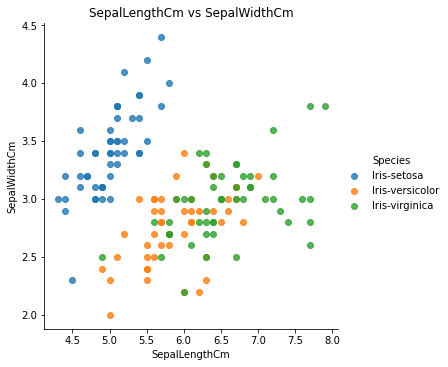

In [4]:
# scatter plot
sns.lmplot(x='SepalLengthCm', y='SepalWidthCm', data=df_dataset, 
           fit_reg=False,   # Sem linha de regressão
           hue='Species')   # Cores diferentes por classe

# cria um título para o gráfico
plt.title('SepalLengthCm vs SepalWidthCm')

# mostra o gráfico
plt.show()

Armazena os dados dentro de uma matriz e as classes dentro de um vetor. As cinco primeiras linhas da matriz de dados e do vetor de classes serão exibidos.

In [1]:
# obtém os valores das n-1 primeiras colunas e guarda em uma matrix X
X = df_dataset[['SepalLengthCm','SepalWidthCm']].values 

# obtém os valores da ultima coluna e guarda em um vetor Y
Y = df_dataset[['Species']].values 
Y = np.ravel( Y ) # converte em um vetor

# imprime as 5 primeiras linhas da matriz X
display('X:', X[0:5,:])

# imprime os 5 primeiros valores de Y
print('Y:', Y[0:5])

NameError: name 'df_dataset' is not defined

Conforme explicado no Capítulo 10 (Avaliação de Modelos Preditivos), a validação *holdout* estratificada consiste em dividir a base de dados em duas partições (treino e teste), mantendo a distribuição original de dados de cada classe em cada partição. Os primeiros $p\%$ dos dados de cada classe devem compor o conjunto de treinamento, enquanto o restante deve compor os dados de teste. Para isso, usaremos a função `sklearn.model_selection.StratifiedShuffleSpli`. 

A função `sklearn.model_selection.StratifiedShuffleSplit` pode ser usada para gerar $n$ particionamentos estratificados. A quantidade de particionamentos é definida pelo parâmetro `n_splits`.  Na validação *holdout*, usamos apenas um particionamento de treino e de teste. Por isso, iremos setar o parâmetro `n_splits` com valor 1. 

É importante que as partições de treinamento e teste sejam geradas de forma aleatória. Para que toda a execução gere o mesmo resultado, vamos usar uma semente para a função de geração de números aleatórios, setando um valor qualquer para o parâmetro `random_state`.

In [6]:
# gera uma divisão dos dados em treino e teste, com 70% de dados para o treinamento e 30% para teste
cv = skl.model_selection.StratifiedShuffleSplit(n_splits=1, test_size=0.3, random_state=2020)

# retorna os índices de treino e teste
train_index, test_index = list( cv.split(X, Y) )[0]

# retorna as partições de treino e teste de acordo com os índices
X_train, X_test = X[train_index, :], X[test_index, :];
Y_train, Y_test = Y[train_index], Y[test_index];

print('Qtd. dados de treinamento: %d (%1.2f%%)' %(X_train.shape[0], (X_train.shape[0]/X.shape[0])*100) )
print('Qtd. de dados de teste: %d (%1.2f%%)' %(X_test.shape[0], (X_test.shape[0]/X.shape[0])*100) )

# imprime a porcentagem de dados de treinamento de cada classe
print("\nQtd. de dados de cada classe (treinamento)")
cTrain, counts_cTrain = np.unique(np.sort(Y_train), return_counts=True)
for i in range( len(cTrain) ):
    print('\tClasse %s: %d (%1.2f%%)' %( cTrain[i],counts_cTrain[i],(counts_cTrain[i]/len(Y_train))*100 ) )

# imprime a porcetagem de dados de teste de cada classe
print("\nQtd. de dados de cada classe (teste)")
cTest, counts_cTest = np.unique(np.sort(Y_test), return_counts=True)
for i in range( len(cTrain) ):
    print('\tClasse %s: %d (%1.2f%%)' %( cTest[i],counts_cTest[i],(counts_cTest[i]/len(Y_test))*100 ) )


Qtd. dados de treinamento: 105 (70.00%)
Qtd. de dados de teste: 45 (30.00%)

Qtd. de dados de cada classe (treinamento)
	Classe Iris-setosa: 35 (33.33%)
	Classe Iris-versicolor: 35 (33.33%)
	Classe Iris-virginica: 35 (33.33%)

Qtd. de dados de cada classe (teste)
	Classe Iris-setosa: 15 (33.33%)
	Classe Iris-versicolor: 15 (33.33%)
	Classe Iris-virginica: 15 (33.33%)


Alguns métodos de aprendizado de máquina são sensíveis à escala dos valores dos atributos. Portanto, vamos normalizar os valores dos atributos para que fiquem com média igual a zero e desvio padrão igual a um. 

In [7]:
# normaliza os valores dos atributos para que fiquem com media igual a zero e desvio padrao igual a um
scaler = skl.preprocessing.StandardScaler().fit(X_train)
X_train = scaler.transform(X_train)
X_test = scaler.transform(X_test)

Agora que separamos os dados em duas partições, podemos treinar um método de classicação na partição de treinamento e testar na partição de teste. Para isso, vamos usar o KNN (Capítulo 4 - Métodos Baseados em Distâncias).

In [8]:
# carrega o classificador
classifier = skl.neighbors.KNeighborsClassifier(n_neighbors=5)

# treina o classificador com os dados de treinameto
classifier.fit(X_train, Y_train) 
 
# classifica os dados de teste
Y_pred = classifier.predict(X_test) 
        
print('\nPredição obtida para as 20 primeiras amostras de teste:\n', Y_pred[0:20])


Predição obtida para as 20 primeiras amostras de teste:
 ['Iris-versicolor' 'Iris-virginica' 'Iris-versicolor' 'Iris-versicolor'
 'Iris-virginica' 'Iris-setosa' 'Iris-versicolor' 'Iris-versicolor'
 'Iris-versicolor' 'Iris-setosa' 'Iris-setosa' 'Iris-setosa'
 'Iris-versicolor' 'Iris-versicolor' 'Iris-virginica' 'Iris-versicolor'
 'Iris-versicolor' 'Iris-versicolor' 'Iris-setosa' 'Iris-setosa']


Vamos dar uma olhada na superfície de decisão aprendida pelo KNN.

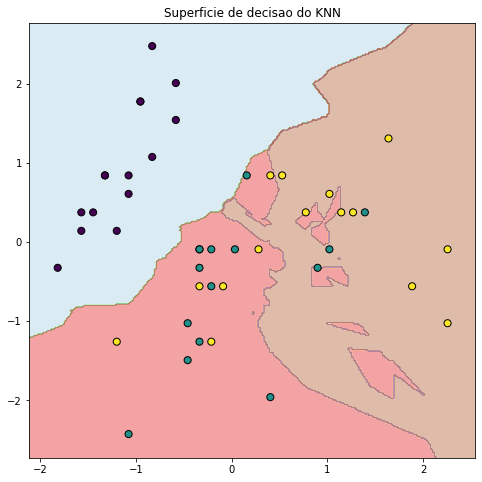

In [9]:
def plota_superficieDecisao(classifier, X, Y, ax, title = ""):
    h = .02  # tamanho do passo da malha (mesh)

    # cria uma malha (mesh)
    x_min, x_max = X[:, 0].min() - 0.3, X[:, 0].max() + 0.3
    y_min, y_max = X[:, 1].min() - 0.3, X[:, 1].max() + 0.3
    xx, yy = np.meshgrid(np.arange(x_min, x_max, h),
                         np.arange(y_min, y_max, h))
     

    # obtem a predicao
    Z = classifier.predict(np.c_[xx.ravel(), yy.ravel()])

    # converte os valores do vetor para indices
    Z2 = np.unique(Z, return_inverse=True)[1]

    # plota a superficie de decisao
    Z2 = Z2.reshape(xx.shape)
    ax.contourf(xx, yy, Z2, cmap=plt.cm.Paired, alpha=.4)

    # converte os valores do vetor para indices
    Y2 = np.unique(Y, return_inverse=True)[1]

    # plota os dados de treinamento
    ax.scatter(X[:, 0], X[:, 1], c=Y2, edgecolor='k', s=50)
    
    ax.set_xlim(xx.min(), xx.max())
    ax.set_ylim(yy.min(), yy.max())
    ax.set_title(title, fontsize='large')
    

# define o tamanho da figura
fig, ax = plt.subplots(figsize=(8, 8)) 

# chama a funcao para plotar a superficie de decisao juntamente com os dados de teste
plota_superficieDecisao(classifier, X_test, Y_test, ax, title = "Superficie de decisao do KNN")

### Matriz de confusão

Agora que treinamos o método de classificação, precisamos avaliar o seu desempenho (Capítulo 10 - Avaliação de Modelos Preditivos). A maioria das medidas de desempenho pode ser calculada a partir da matriz de confusão. A Tabela 1 apresenta um exemplo de matriz de confusão para um problema com duas classes: **pos** e **neg**. 

 <table style="text-align:center">
  <tr>
    <th> </th>
    <th>Predição = pos</th>
    <th>Predição = neg</th>
  </tr>
  <tr>
    <td><b>Classe = pos</b></td>
    <td>vp</td>
    <td>fn</td>
  </tr>
  <tr>
      <td><b>Classe = neg</b></td>
    <td>fp</td>
    <td>vn</td>
  </tr>
</table> 
<br/>
<center><em>Tabela 1. Exemplo de matriz de confusão para um problema binário.</em></center>
<br/>

A partir da matriz de confusão mostrada acima, podemos coletar os seguintes valores:

* **verdadeiros positivos (vp)**: quantidade de exemplos corretamente classificados como pertencentes à classe positiva.
* **falsos positivos (fp)**: quantidade de exemplos incorretamente classificados como pertencentes à classe positiva.
* **verdadeiros negativos (vn)**: quantidade de exemplos corretamente classificados como pertencentes à classe negativa.
* **falsos negativos (fn)**: quantidade de exemplos incorretamente classificados como pertencentes à classe negativa.

A matriz de confusão apresentada na Tabela 1 pode ser facilmente estendida para problemas multiclasse. Para um problema de $|C|$ classes, a matriz de confusão terá dimensão $|C|\times|C|$ e pode ser representada conforme mostra a Tabela 2.

 <table>
  <tr style="text-align:center">
    <th> </th>
    <th style="text-align:center">Predição = $c_1$</th>
    <th style="text-align:center">Predição = $c_2$</th>
    <th style="text-align:center">$\dots$</th>
    <th style="text-align:center">Predição = $c_{|C|}$</th>
  </tr>
  <tr style="text-align:center">
    <td style="text-align:center"><b>Classe = $c_1$</b></td>
    <td style="text-align:center">$k_{11}$</td>
    <td style="text-align:center">$k_{12}$</td>
    <td style="text-align:center">$\dots$</td>
    <td style="text-align:center">$k_{1|C|}$</td>
  </tr>
  <tr style="text-align:center">
    <td style="text-align:center"><b>Classe = $c_2$</b></td>
    <td style="text-align:center">$k_{21}$</td>
    <td style="text-align:center">$k_{22}$</td>
    <td style="text-align:center">$\dots$</td>
    <td style="text-align:center">$k_{2|C|}$</td>
  </tr>
  <tr style="text-align:center">
    <td style="text-align:center"><b>$\vdots$</b></td>
    <td style="text-align:center">$\vdots$</td>
    <td style="text-align:center">$\vdots$</td>
    <td style="text-align:center">$\ddots$</td>
    <td style="text-align:center">$\vdots$</td>
  </tr>
  <tr style="text-align:center">
    <td style="text-align:center"><b>Classe = $c_{|C|}$</b></td>
    <td style="text-align:center">$k_{|C|1}$</td>
    <td style="text-align:center">$k_{|C|2}$</td>
    <th style="text-align:center">$\dots$</th>
    <td style="text-align:center">$k_{|C||C|}$</td>
  </tr>
</table> 
<br/>
<center><em>Tabela 2. Exemplo de matriz de confusão para um problema multiclasse.</em></center>

A quantidade de **vp**, **vn**, **fp** e **fn** em relação a uma classe $c_j$, usando os valores apresentados na matriz de confusão (Tabela 2), pode ser calculada da seguinte forma:

* $\text{vp}_j=k_{jj}$: quantidade de exemplos corretamente classificados como pertencentes à classe $c_j$;

* $\text{fp}_j=\sum_{p=1|p\neq j}^{{|\mathcal{C}|}} k_{pj}$: quantidade de exemplos incorretamente classificados como pertencentes à classe $c_j$; 
 
* $\text{vn}_j=\sum_{i=1|i\neq j}^{{|\mathcal{C}|}} \sum_{p=1|p\neq j}^{{|\mathcal{C}|}} k_{pi}$: quantidade de exemplos corretamente classificados como não pertencentes à classe $c_j$; 

* $\text{fn}_j=\sum_{p=1|p\neq j}^{{|\mathcal{C}|}} k_{jp}$: quantidade de exemplos da classe $c_j$ incorretamente classificados como pertencentes a outra classe. 

Outra maneira de calcular **vp**, **vn**, **fp** e **fn** para uma classe $c_j$ em um problema multiclasse é gerar uma matriz de confusão binária onde $c_j$ é considerada a classe positiva e todas as outras são consideradas uma única classe negativa.

Usando a biblioteca `scikit-learn`, podemos obter a matriz de confusão usando a função `sklearn.metrics.confusion_matrix`.

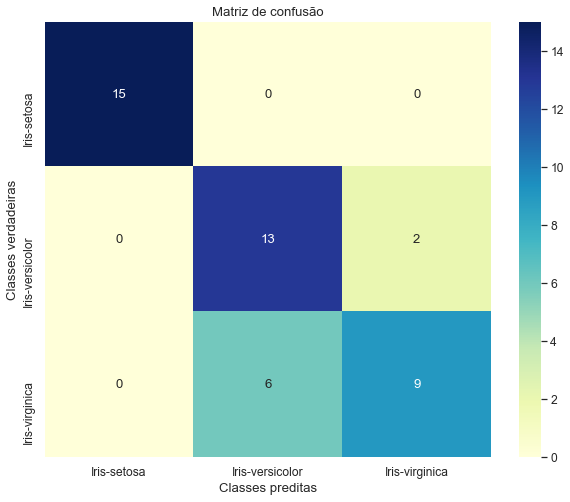

In [11]:
# obtem as classes 
classesDataset = np.unique(Y_train)

# obtem a matriz de confusão
cm = skl.metrics.confusion_matrix(Y_test, Y_pred, classesDataset)

# vamos plotar a matriz de confusao 

# definindo o tamanho da figura 
plt.figure(figsize=(10,8))
    
# cria um mapa de cores dos valores da matriz de confusao
sns.heatmap(cm, xticklabels=classesDataset, yticklabels=classesDataset, cmap="YlGnBu", annot=True)
sns.set(font_scale=1.1) # aumenta a escala das fontes do grafico
        
plt.xlabel('Classes preditas')
plt.ylabel('Classes verdadeiras')
plt.title('Matriz de confusão')
plt.show()

### Medidas de desempenho

Vamos calcular o desempenho do algoritmo de classificação (Capítulo 10 - Avaliação de Modelos Preditivos). Algumas medidas de desempenho (*e.g.*, acurácia) retornam um valor global de desempenho, enquanto que outras (*e.g.*, precisão, revocação e F-medida) retornam um valor que pode variar dependendo de qual classe é considerada como positiva (classe alvo do problema). Supondo que em um determinado problema, a classe $c_1$ seja considerada a classe positiva, as seguintes medidas de desempenho podem ser calculadas:

* $\displaystyle \text{acurácia} =\frac{vp_1+vn_1}{vp_1+vn_1+fp_1+fn_1} = \frac{\text{Qtd. de predições corretas}}{\text{Qtd. de amostras}};$

* $\displaystyle \text{revocação} =  \frac{vp_1}{vp_1+fn_1} \text{;} $

* $\displaystyle \text{precisão} = \frac{vp_1}{vp_1+fp_1}; $

* $\displaystyle \text{F-medida} = 2 \times \frac{\text{precisão} \times\text{revocação}}{\text{precisão}+\text{revocação}}.$

Para problemas binários sem uma classe-alvo ou para problemas multiclasse, normalmente são utilizadas medidas de desempenho que consideram a média entre os resultados relativos a cada classe do problema. As duas principais estratégias para obter a média de desempenho entre as classes são a média macro e a média micro. A média macro considera que todas as classes possuem a mesma importância. Por outro lado, na média micro, o resultado final é dominado pelas classes mais frequentes, o que pode gerar um desempenho superestimado quando as classes são muito desbalanceadas. Abaixo, são apresentadas algumas medidas de desempenho calculadas por meio dessas duas estratégias.

* Medidas baseadas na média macro:
 - $ \displaystyle \text{macro revocação} = \frac{1}{{|\mathcal{C}|}} \times \sum_{j=1}^{{|\mathcal{C}|}} \frac{vp_j}{vp_j+fn_j}$;
		
 - $ \displaystyle \text{macro precisão} = \frac{1}{{|\mathcal{C}|}} \times \sum_{j=1}^{{|\mathcal{C}|}} \frac{vp_j}{vp_j+fp_j}$;
		
 - $ \displaystyle \text{macro F-medida} = 2 \times \frac{\text{macro precisão} \times\text{macro revocação}}{\text{macro precisão}+\text{macro revocação}}$.


* Medidas baseadas na média micro:
 - $ \displaystyle \text{micro revocação} = \frac{\sum_{j=1}^{{|\mathcal{C}|}} vp_j}{\sum_{j=1}^{{|\mathcal{C}|}} vp_j+fn_j}$;

 - $ \displaystyle \text{micro precisão} = \frac{\sum_{j=1}^{{|\mathcal{C}|}} vp_j}{\sum_{j=1}^{{|\mathcal{C}|}} vp_j+fp_j}$; 

 - $ \displaystyle \text{micro F-medida} = 2 \times \frac{\text{micro precisão} \times\text{micro revocação}}{\text{micro precisão}+\text{micro revocação}}$.

Na função abaixo, será gerado um relatório com as principais medidas de desempenho. Será calculada a **precisão**, **revocação** e **F-medida** para cada uma das classes do problema. Adicionalmente, será calculada a **acurácia**, **macro** e **micro precisão**, **macro** e **micro revocação** e, por fim, a **macro** e **micro F-medida**.

In [13]:
def relatorioDesempenho(Y_test, Y_pred, classes, imprimeRelatorio=False):
  """
  Funcao usada calcular as medidas de desempenho da classificação.
  
  Parametros
  ----------   
    
  classes: classes do problema
  
  imprimeRelatorio: variavel booleana que indica se o relatorio de desempenho
                    deve ser impresso ou nao. 
     
  Retorno
  -------
  resultados: variavel do tipo dicionario (dictionary). As chaves
              desse dicionario serao os nomes das medidas de desempenho; os valores
              para cada chave serao as medidas de desempenho calculadas na funcao.
              
              Mais especificamente, o dicionario devera conter as seguintes chaves:
              
               - acuracia: valor entre 0 e 1 
               - revocacao: um vetor contendo a revocacao obtida em relacao a cada classe
                            do problema
               - precisao: um vetor contendo a precisao obtida em relacao a cada classe
                            do problema
               - fmedida: um vetor contendo a F-medida obtida em relacao a cada classe
                            do problema
               - revocacao_macroAverage: valor entre 0 e 1
               - precisao_macroAverage: valor entre 0 e 1
               - fmedida_macroAverage: valor entre 0 e 1
               - revocacao_microAverage: valor entre 0 e 1
               - precisao_microAverage: valor entre 0 e 1
               - fmedida_microAverage: valor entre 0 e 1
  """

  # obtem a quantidade de classes
  nClasses = len(classes)

  # obtem a acuracia
  acuracia = metrics.accuracy_score(Y_test, Y_pred)
    
  # inicializa as medidas de desempenho 
  revocacao = np.zeros( len(classes) )
  precisao = np.zeros( len(classes) )
  fmedida = np.zeros( len(classes) )
    
  # calcula a medida de desempenho para cada classe individualmente
  for i in range( len(classes) ):
    
      # transforma o problema multiclasse em binário, apenas para calcular o desempenho individual da classe i
      auxY_test = np.zeros( len(Y_test) ) # inicializa o vetor de classes binárias com 0
      auxY_pred = np.zeros( len(Y_pred) ) # inicializa o vetor de classes binárias com 0
      auxY_test[Y_test==classes[i]] = 1 # onde a classe for igual a classe[i], recebe valor 1
      auxY_pred[Y_pred==classes[i]] = 1 # onde a classe for igual a classe[i], recebe valor 1
        
      revocacao[i] = metrics.recall_score(auxY_test, auxY_pred, pos_label=1) # revocacao
      precisao[i] = metrics.precision_score(auxY_test, auxY_pred, pos_label=1) # precisao
      fmedida[i] = metrics.f1_score(auxY_test, auxY_pred, pos_label=1) # f-medida 
  

  revocacao_microAverage =  metrics.recall_score(Y_test, Y_pred, average='micro')
  precisao_microAverage = metrics.precision_score(Y_test, Y_pred, average='micro')
  fmedida_microAverage = metrics.f1_score(Y_test, Y_pred, average='micro')

  revocacao_macroAverage =  metrics.recall_score(Y_test, Y_pred, average='macro')
  precisao_macroAverage = metrics.precision_score(Y_test, Y_pred, average='macro')
  fmedida_macroAverage = metrics.f1_score(Y_test, Y_pred, average='macro')
  
  
  # imprime os resultados para cada classe
  if imprimeRelatorio:
        
      print('\n\tRevocacao   Precisao   F-medida   Classe')
      for i in range(nClasses):
        print('\t%1.3f       %1.3f      %1.3f      %s' % (revocacao[i], precisao[i], fmedida[i],classes[i] ) )
    
      print('\t------------------------------------------------');
      
      #imprime as médias
      print('\t%1.3f       %1.3f      %1.3f      Média macro' % (revocacao_macroAverage, precisao_macroAverage, fmedida_macroAverage) )
      print('\t%1.3f       %1.3f      %1.3f      Média micro\n' % (revocacao_microAverage, precisao_microAverage, fmedida_microAverage) )
    
      print('\tAcuracia: %1.3f' %acuracia)
      
  # armazena os resultados em uma estrutura tipo dicionario
  resultados = {'revocacao': revocacao, 'acuracia': acuracia, 'precisao':precisao, 'fmedida':fmedida}
  resultados.update({'revocacao_macroAverage':revocacao_macroAverage, 'precisao_macroAverage':precisao_macroAverage, 'fmedida_macroAverage':fmedida_macroAverage})
  resultados.update({'revocacao_microAverage':revocacao_microAverage, 'precisao_microAverage':precisao_microAverage, 'fmedida_microAverage':fmedida_microAverage})

  return resultados 

# chama a funcao que gera o relatorio de desempenho
auxResults = relatorioDesempenho(Y_test, Y_pred, classesDataset, imprimeRelatorio=True)


	Revocacao   Precisao   F-medida   Classe
	1.000       1.000      1.000      Iris-setosa
	0.867       0.684      0.765      Iris-versicolor
	0.600       0.818      0.692      Iris-virginica
	------------------------------------------------
	0.822       0.834      0.819      Média macro
	0.822       0.822      0.822      Média micro

	Acuracia: 0.822


### Busca em grade

O melhor número de vizinhos para usar como parâmetro do KNN pode variar dependendo do problema (Capítulo 4 - Métodos Baseados em Distâncias). Em alguns problemas, 1 vizinho pode gerar bons resultados, mas em outros talvez seja necessário usar mais. Para não ter que ficar tentando acertar o melhor parâmetro, é recomendado usar uma busca em grade para testar um conjunto de valores (*e.g.*, ${1,3,5,11,21,31})$ na predição do conjunto de validação. Posteriormente, o melhor valor encontrado pode ser usado para avaliar o método nos dados de teste. 

Na função `skl.neighbors.KNeighborsClassifier()`, o parâmetro usado para definir o número de vizinhos é o `n_neighbors `. O melhor valor para esse parâmetro será escolhido pela busca em grade que pode ser executada usando a função `skl.model_selection.GridSearchCV()`. Os possíveis valores que serão avaliados pela busca em grade devem ser informados por meio do parâmetro `param_grid`.

In [16]:
# inicia o classificador com os parâmetros default do Scikit
KNNClassifier = skl.neighbors.KNeighborsClassifier()

# número de vizinhos que serão testados na busca em grade {1,3,5,...,15}
param_grid = {'n_neighbors': np.arange(1,16,2)} 

# validação cruzada que sera usada na busca em grade
cvGrid = skl.model_selection.StratifiedShuffleSplit(n_splits=1, test_size=0.3, random_state=2020)

# inicia a busca em grade
classifier = skl.model_selection.GridSearchCV(KNNClassifier, cv=cvGrid, param_grid=param_grid, scoring = 'f1_macro')

print('Classificador inicializado com sucesso')

Classificador inicializado com sucesso


Agora, podemos treinar o método de classicação. Internamente, a função `fit()` irá executar a busca em grade e escolher o melhor valor para o número de vizinhos usados pelo KNN. 

In [17]:
# treina o classificador com os dados de treinameto
classifier.fit(X_train, Y_train) 

# obtem o melhor classificador encontrado na busca em grade
classifier_best = classifier.best_estimator_
 
print('\nQtd. de vizinhos escolhida na busca em grade')
print('Parâmetro: ', classifier.best_params_['n_neighbors'], '-- Score: ', "{0:.3f}".format(classifier.best_score_))

print("\nMacro F-medida obtida para cada parametro testado na busca em grade:")
print()
means = classifier.cv_results_['mean_test_score']
for mean, params in zip(means, classifier.cv_results_['params']):
    print("n_neighbors = %d -- Macro F-medida = %0.3f" % (params['n_neighbors'],mean))
    
#classifier.cv_results_  


Qtd. de vizinhos escolhida na busca em grade
Parâmetro:  13 -- Score:  0.802

Macro F-medida obtida para cada parametro testado na busca em grade:

n_neighbors = 1 -- Macro F-medida = 0.648
n_neighbors = 3 -- Macro F-medida = 0.741
n_neighbors = 5 -- Macro F-medida = 0.774
n_neighbors = 7 -- Macro F-medida = 0.676
n_neighbors = 9 -- Macro F-medida = 0.741
n_neighbors = 11 -- Macro F-medida = 0.741
n_neighbors = 13 -- Macro F-medida = 0.802
n_neighbors = 15 -- Macro F-medida = 0.802


Realiza a predição das amostras de teste usando o classificador treinado e imprime o relatório de resultados.

In [18]:
# classifica os dados de teste
Y_pred = classifier.predict(X_test) 

resultados = relatorioDesempenho(Y_test, Y_pred, classesDataset, imprimeRelatorio=True)


	Revocacao   Precisao   F-medida   Classe
	1.000       1.000      1.000      Iris-setosa
	0.733       0.647      0.688      Iris-versicolor
	0.600       0.692      0.643      Iris-virginica
	------------------------------------------------
	0.778       0.780      0.777      Média macro
	0.778       0.778      0.778      Média micro

	Acuracia: 0.778


Vamos dar uma olhada na superfície de decisão do classificador

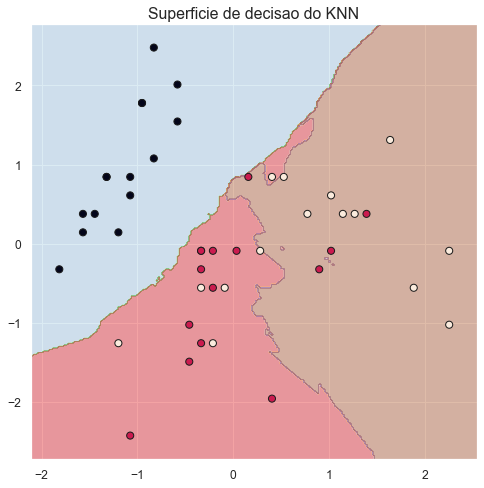

In [19]:
# define o tamanho da figura
fig, ax = plt.subplots(figsize=(8, 8)) 

# chama a funcao para plotar a superficie de decisao juntamente com os dados de teste
plota_superficieDecisao(classifier, X_test, Y_test, ax, title = "Superficie de decisao do KNN")

---
## Validação cruzada K-fold 

A validação cruzada $k$-fold é considerada mais robusta que a validação por *holdout*, pois ela garante que o algoritmo será avaliado com todas as amostras da base de dados (Capítulo 10 - Avaliação de Modelos Preditivos).

Para prosseguir com os experimentos com essa nova validação, vamos carregar os dados novamente.

In [20]:
# Obtem os valores das n-1 primeiras colunas e guarda em uma matrix X
X = df_dataset[['SepalLengthCm','SepalWidthCm']].values 

# Obtem os valores da ultima coluna e guarda em um vetor Y
Y = df_dataset[['Species']].values 
Y = np.ravel( Y ) # converte em um vetor

# Imprime as 5 primeiras linhas da matriz X
display('X:', X[0:5,:])

# Imprime os 5 primeiros valores de Y
print('Y:', Y[0:5])

# Obtem e imprimi as classes do problema
classes = np.unique(Y)
print('\nClasses: ', classes)

'X:'

array([[5.1, 3.5],
       [4.9, 3. ],
       [4.7, 3.2],
       [4.6, 3.1],
       [5. , 3.6]])

Y: ['Iris-setosa' 'Iris-setosa' 'Iris-setosa' 'Iris-setosa' 'Iris-setosa']

Classes:  ['Iris-setosa' 'Iris-versicolor' 'Iris-virginica']


Agora, você deverá usar a validação cruzada *k*-fold estratificada. Na versão estratificada, cada partição deve conter aproximadamente a mesma distribuição original de dados de cada classe. Na sua implementação, você deve dividir os dados em $k$ folds. Para cada rodada $k$, os dados da $k$-ésima partição devem compor os dados de teste, enquanto os dados das outras partições devem compor os dados de treinamento. É importante que as $k$ partições sejam geradas de forma aleatória. Para que toda a execução gere o mesmo resultado, vamos usar uma semente para a função de geração de números aleatórios. 

In [21]:
# semente usada na randomizacao dos dados
randomSeed = 2020 

# separa os dados em k folds
nFolds = 5

# gera as particoes
cv = skl.model_selection.StratifiedKFold(n_splits=nFolds, shuffle=True, random_state = randomSeed)

# imprime algumas informacoes sobre cada particao
k = 1
for train_index, test_index in cv.split(X, Y):

    print('\n-----------\n%d-fold: \n-----------\n' % (k) )

    # se train_index ou test_index forem vazios, interrompe o laco de repeticao
    if len(train_index)==0 or len(test_index)==0: 
        print('\tErro: o vetor com os indices de treinamento ou o vetor com os indices de teste esta vazio')      
        break
        
    X_train, X_test = X[train_index, :], X[test_index, :];
    Y_train, Y_test = Y[train_index], Y[test_index];

    print('\tQtd. dados de treinamento: %d (%1.2f%%)' %(X_train.shape[0], (X_train.shape[0]/X.shape[0])*100) )
    print('\tQtd. de dados de teste: %d (%1.2f%%)' %(X_test.shape[0], (X_test.shape[0]/X.shape[0])*100) )

    # imprime a porcentagem de dados de treinamento de cada classe
    print("\n\tQtd. de dados de cada classe (treinamento)")
    cTrain, counts_cTrain = np.unique(np.sort(Y_train), return_counts=True)
    for i in range( len(cTrain) ):
        print('\t\tClasse %s: %d (%1.2f%%)' %( cTrain[i],counts_cTrain[i],(counts_cTrain[i]/len(Y_train))*100 ) )

    # imprime a porcetagem de dados de teste de cada classe
    print("\n\tQtd. de dados de cada classe (teste)")
    cTest, counts_cTest = np.unique(np.sort(Y_test), return_counts=True)
    for i in range( len(cTrain) ):
        print('\t\tClasse %s: %d (%1.2f%%)' %( cTest[i],counts_cTest[i],(counts_cTest[i]/len(Y_test))*100 ) )

    k = k + 1


-----------
1-fold: 
-----------

	Qtd. dados de treinamento: 120 (80.00%)
	Qtd. de dados de teste: 30 (20.00%)

	Qtd. de dados de cada classe (treinamento)
		Classe Iris-setosa: 40 (33.33%)
		Classe Iris-versicolor: 40 (33.33%)
		Classe Iris-virginica: 40 (33.33%)

	Qtd. de dados de cada classe (teste)
		Classe Iris-setosa: 10 (33.33%)
		Classe Iris-versicolor: 10 (33.33%)
		Classe Iris-virginica: 10 (33.33%)

-----------
2-fold: 
-----------

	Qtd. dados de treinamento: 120 (80.00%)
	Qtd. de dados de teste: 30 (20.00%)

	Qtd. de dados de cada classe (treinamento)
		Classe Iris-setosa: 40 (33.33%)
		Classe Iris-versicolor: 40 (33.33%)
		Classe Iris-virginica: 40 (33.33%)

	Qtd. de dados de cada classe (teste)
		Classe Iris-setosa: 10 (33.33%)
		Classe Iris-versicolor: 10 (33.33%)
		Classe Iris-virginica: 10 (33.33%)

-----------
3-fold: 
-----------

	Qtd. dados de treinamento: 120 (80.00%)
	Qtd. de dados de teste: 30 (20.00%)

	Qtd. de dados de cada classe (treinamento)
		Classe Iri

Agora que separamos os dados em partições, vamos executar o algoritmo em cada *fold* gerado e calcular o resultado. Em cada *fold*, deve ser usada a busca em grade para encontrar o melhor número de vizinhos. Além disso, para cada *fold*, antes de apresentar os dados para o KNN, os dados devem ser normalizados.

In [22]:
k = 1
resultados=[] # cria uma lista vazia para guardar algumas informacoes do experimento

for train_index, test_index in cv.split(X, Y):
    print('\n-----------\nFold %d: \n-----------\n' % (k) )

    X_train, X_test = X[train_index, :], X[test_index, :];
    Y_train, Y_test = Y[train_index], Y[test_index];
    
    # normaliza os valores dos atributos para que fiquem com media igual a zero e desvio padrao igual a um
    scaler = skl.preprocessing.StandardScaler().fit(X_train)
    X_train = scaler.transform(X_train)
    X_test = scaler.transform(X_test)
  
    # inicia um timer para analisar o tempo levado para o treinamento e teste
    startTime = time.time() 
    
    # inicia o classificador com os parâmetros default do Scikit
    KNNClassifier = skl.neighbors.KNeighborsClassifier()

    # número de vizinhos que serão testados na busca em grade {1,3,5,...,15}
    param_grid = {'n_neighbors': np.arange(1,16,2)} 

    # validação cruzada que sera usada na busca em grade
    cvGrid = skl.model_selection.StratifiedShuffleSplit(n_splits=1, test_size=0.2)
    
    # inicia a busca em grade
    classifier = skl.model_selection.GridSearchCV(KNNClassifier, cv=cvGrid, param_grid=param_grid, scoring = 'f1_macro')

    # treina o classificador com os dados de treinameto
    classifier.fit(X_train, Y_train) 

    # classifica os dados de teste
    Y_pred = classifier.predict(X_test)
    
    # calcula o tempo despendido no treinamento e no teste
    timeFolds = time.time() - startTime

    # gera o relatório de desempenho
    auxResults = relatorioDesempenho(Y_test, Y_pred, classesDataset, imprimeRelatorio=True)

    print( '\n\tTempo (segundos): %1.5f' %timeFolds)
    
    # acrescenta o tempo aos resultados
    auxResults.update({'timeFolds': timeFolds})

    # guarda o classificador dentro de resultados
    auxResults.update({'classifier': classifier})
    
    # adiciona os resultados do fold atual na lista de resultados
    resultados.append( auxResults ) 
        
    k+=1


-----------
Fold 1: 
-----------


	Revocacao   Precisao   F-medida   Classe
	1.000       1.000      1.000      Iris-setosa
	0.500       0.833      0.625      Iris-versicolor
	0.900       0.643      0.750      Iris-virginica
	------------------------------------------------
	0.800       0.825      0.792      Média macro
	0.800       0.800      0.800      Média micro

	Acuracia: 0.800

	Tempo (segundos): 0.05325

-----------
Fold 2: 
-----------


	Revocacao   Precisao   F-medida   Classe
	1.000       1.000      1.000      Iris-setosa
	0.700       0.778      0.737      Iris-versicolor
	0.800       0.727      0.762      Iris-virginica
	------------------------------------------------
	0.833       0.835      0.833      Média macro
	0.833       0.833      0.833      Média micro

	Acuracia: 0.833

	Tempo (segundos): 0.04356

-----------
Fold 3: 
-----------


	Revocacao   Precisao   F-medida   Classe
	1.000       1.000      1.000      Iris-setosa
	0.400       0.500      0.444      Iris-ver

Agora, precisamos calcular o desempenho final do algoritmo. Para isso, basta calcular a média dos resultados obtidos em cada fold. Adicionalmente, pode ser apresentado o desvio padrão também. 

In [23]:
def mediaFolds( resultados, classes ):
    
    nClasses = len(classes)
    
    acuracia = np.zeros( len(resultados) )
    timeFolds = np.zeros( len(resultados) )
    
    revocacao = np.zeros( [len(resultados),len(classes)] )
    precisao = np.zeros( [len(resultados),len(classes)] )
    fmedida = np.zeros( [len(resultados),len(classes)] )

    revocacao_macroAverage = np.zeros( len(resultados) )
    precisao_macroAverage = np.zeros( len(resultados) )
    fmedida_macroAverage = np.zeros( len(resultados) )

    revocacao_microAverage = np.zeros( len(resultados) )
    precisao_microAverage = np.zeros( len(resultados) )
    fmedida_microAverage = np.zeros( len(resultados) )

    for i in range(len(resultados)):
        acuracia[i] = resultados[i]['acuracia']
        
        revocacao[i,:] = resultados[i]['revocacao']
        precisao[i,:] = resultados[i]['precisao']
        fmedida[i,:] = resultados[i]['fmedida']

        revocacao_macroAverage[i] = resultados[i]['revocacao_macroAverage']
        precisao_macroAverage[i] = resultados[i]['precisao_macroAverage']
        fmedida_macroAverage[i] = resultados[i]['fmedida_macroAverage']

        revocacao_microAverage[i] = resultados[i]['revocacao_microAverage']
        precisao_microAverage[i] = resultados[i]['precisao_microAverage']
        fmedida_microAverage[i] = resultados[i]['fmedida_microAverage']
        
        timeFolds[i] = resultados[i]['timeFolds']
        
    # imprimindo os resultados para cada classe
    print('\n\tRevocacao             Precisao             F-medida             Classe')
    for i in range(0,nClasses):
        print('\t%1.3f (+-%1.3f)       %1.3f (+-%1.3f)      %1.3f (+-%1.3f)      %s' % (np.mean(revocacao[:,i]), np.std(revocacao[:,i]), 
                                                                    np.mean(precisao[:,i]), np.std(precisao[:,i]), 
                                                                    np.mean(fmedida[:,i]), np.std(fmedida[:,i]), classes[i] ) )

    print('\t---------------------------------------------------------------------')
  
    #imprime as medias
    print('\t%1.3f (+-%1.3f)       %1.3f (+-%1.3f)      %1.3f (+-%1.3f)      Média macro' % (np.mean(revocacao_macroAverage), np.std(revocacao_macroAverage), 
                                                                                             np.mean(precisao_macroAverage), np.std(precisao_macroAverage), 
                                                                                             np.mean(fmedida_macroAverage), np.std(fmedida_macroAverage) ) )
    print('\t%1.3f (+-%1.3f)       %1.3f (+-%1.3f)      %1.3f (+-%1.3f)      Média micro\n' % (np.mean(revocacao_microAverage), np.std(revocacao_microAverage),  
                                                                                               np.mean(precisao_microAverage), np.std(precisao_microAverage),
                                                                                               np.mean(fmedida_microAverage), np.std(fmedida_microAverage)) )

    print('\tAcuracia: %1.3f' %np.mean(acuracia))
    print('\tTempo (em segundos): %1.5f (+-%1.5f) ' %(np.mean(timeFolds), np.std(timeFolds)) )

# imprime a media dos folds
print('\nResultado final da classificação:')
mediaFolds( resultados, classes )


Resultado final da classificação:

	Revocacao             Precisao             F-medida             Classe
	0.980 (+-0.040)       1.000 (+-0.000)      0.989 (+-0.021)      Iris-setosa
	0.600 (+-0.179)       0.671 (+-0.133)      0.612 (+-0.097)      Iris-versicolor
	0.680 (+-0.214)       0.647 (+-0.089)      0.636 (+-0.129)      Iris-virginica
	---------------------------------------------------------------------
	0.753 (+-0.062)       0.773 (+-0.060)      0.746 (+-0.065)      Média macro
	0.753 (+-0.062)       0.753 (+-0.062)      0.753 (+-0.062)      Média micro

	Acuracia: 0.753
	Tempo (em segundos): 0.04777 (+-0.00470) 


Pelos resultados mostrados acima, pode-se concluir que as medidas de desempenho tiveram pouca variação entre os *folds* avaliados, uma vez que o desvio padrão foi baixo para todas elas. Ainda, as classes *Iris-virginica* e *Iris-versicolor* parecem ser mais difíceis de serem preditas, pois o desempenho do classificador nessas classes foi inferior. 

Além das medidas de desempenho, dentro da variável resultados, nós também armazenamos os classificadores gerados em cada *fold*. Vamos, dar uma olhada na superfície de decisão gerada individualmente por cada classificador.

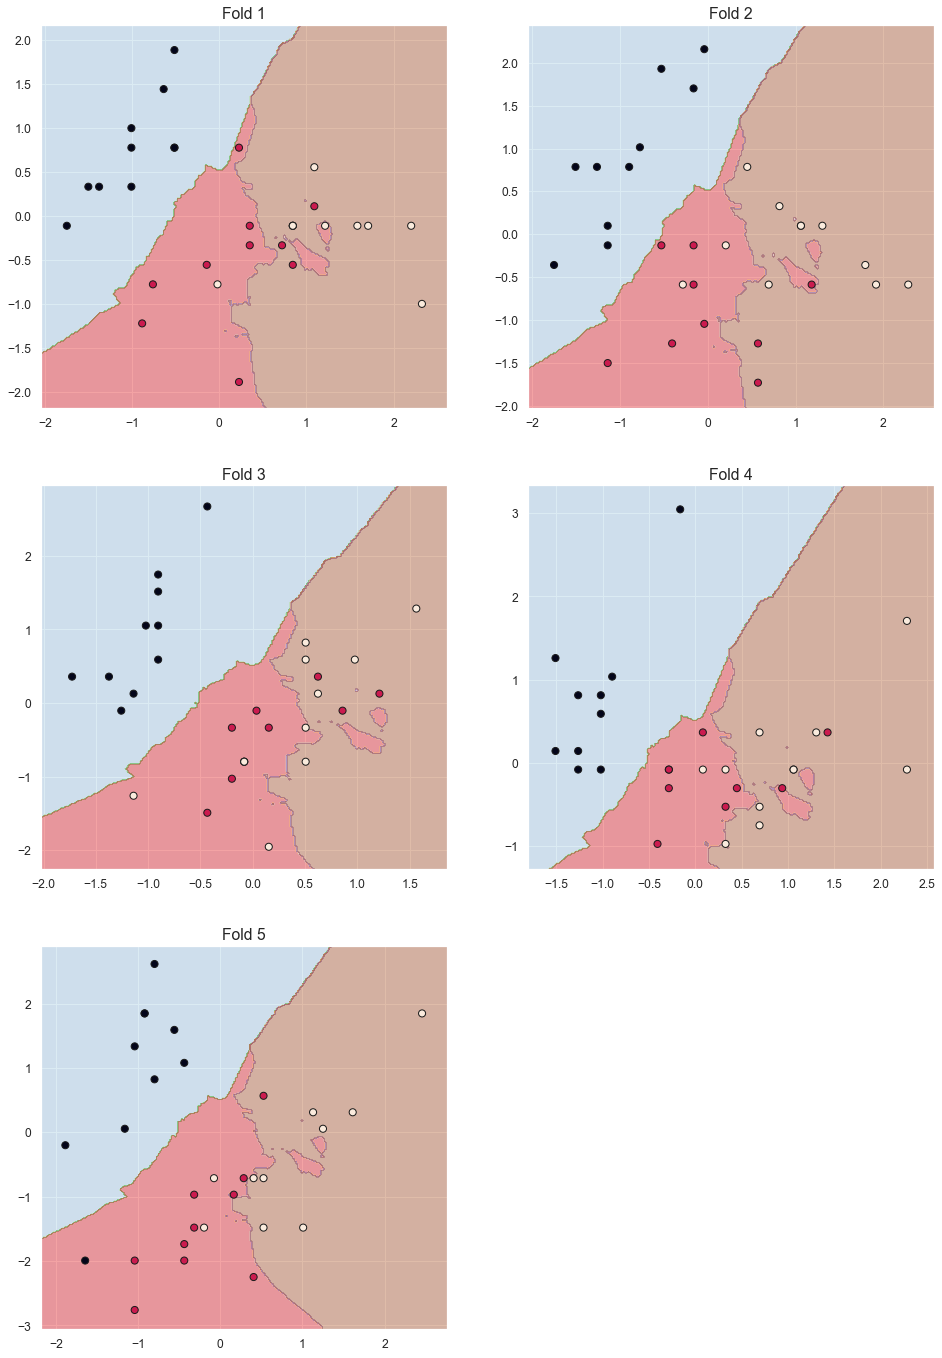

In [24]:
# define a quantidade de linhas e colunas e o tamanho da figura
nrows = 3; ncols=2; 
fig, axs = plt.subplots(nrows=nrows, ncols=ncols, figsize=(8*ncols, 8*nrows))

# apaga a ultima figura 
fig.delaxes(axs[2,1]) #The indexing is zero-based here

# converte o array em um vetor
axs = np.concatenate(axs)

k = 1
for train_index, test_index in cv.split(X, Y):
    #print('\n-----------\nFold %d: \n-----------\n' % (k) )

    X_train, X_test = X[train_index, :], X[test_index, :];
    Y_train, Y_test = Y[train_index], Y[test_index];

    # normaliza os valores dos atributos para que fiquem com media igual a zero e desvio padrao igual a um
    scaler = skl.preprocessing.StandardScaler().fit(X_train)
    X_train = scaler.transform(X_train)
    X_test = scaler.transform(X_test)
    
    plota_superficieDecisao(resultados[i-1]['classifier'], X_test, Y_test, axs[k-1], title = 'Fold %d'%k )
    
    k=k+1

---
## Comparando o desempenho de métodos de classificação

Vamos fazer a comparação do desempenho de diferentes métodos de classificação: K-vizinhos mais próximos (*K-nearest neighbors* - KNN) [1] (Capítulo 4 - Métodos Baseados em Distâncias), *naive* Bayes Gaussiano (*Gaussian naive* Bayes - G.NB) [2] (Capítulo 5 - Métodos Probabilísticos), máquinas de vetores de suporte (*support vector machines* - SVM) [3] (Capítulo 8 - Métodos de Maximização de Margens), árvores de decisão (*decision trees* - DT) [4] (Capítulo 6 - Métodos Simbólicos) e regressão logística (*logistic regression* - LR) [5].

Primeiro, vamos criar uma função que recebe o nome de um método e retorna o objeto relativo a ele já inicializado e com os parâmetros definidos. Para alguns métodos, como o SVM e KNN, usaremos uma busca em grade para selecionar os valores para dos principais parâmetros.


In [25]:
def return_classifier(method):
    """
    Função usada para selecionar um método de classificação para ser usado no experimento
    
    Parametros:
    -----------
    method: string
        Um nome usado para identificar

        'G.NB': Naive Bayes Gaussiano
        'SVM': Support vector machines
        'DT': Decision trees
        'LR': Logistic regression
        'KNN': k-nearest neighbors 
    """  

    # validação cruzada que sera usada na busca em grade
    cvGrid = skl.model_selection.StratifiedShuffleSplit(n_splits=1, test_size=0.3)
    
    if method == 'G.NB': # Naive Bayes Gaussiano
        # inicia o classificador
        classifier = skl.naive_bayes.GaussianNB()  
        
    elif method == 'SVM':
        # inicia o classificador com os parâmetros default do Scikit
        classifier_svm = skl.svm.SVC()
        
        # alguns métodos (e.g. SVM, KNN e Florestas aleatórias) são sensíveis a variação de parâmetros. 
        # Por isso, é recomendado selecionar os parâmetros usando uma busca em grade.
        param_grid = [
              {'C': [2**-5, 2**0, 2**5, 2**10, 2**15], 'kernel': ['linear']},
              {'C': [2**-5, 2**0, 2**5, 2**10, 2**15], 'gamma': [1e-3, 1e-4], 'kernel': ['rbf']},
        ]
        
        # inicia o classificador SVM, implementado usando uma busca em grade
        classifier = skl.model_selection.GridSearchCV(classifier_svm, cv=cvGrid, param_grid=param_grid, scoring = 'f1_macro')       
                
    elif method == 'DT': # Árvores de decisão 
        # inicia o classificador
        classifier = skl.tree.DecisionTreeClassifier(random_state = 5)
        
    elif method == 'LR': # Regressão logística
        # inicia o classificador
        classifier = skl.linear_model.LogisticRegression() 

    elif method == 'KNN': # K-Vizinhos mais próximos
        # inicia o classificador com os parâmetros default do Scikit
        classifier_knn  = skl.neighbors.KNeighborsClassifier()
        
        # seleciona a quantidade de vizinhos usando busca em grade
        param_grid = {'n_neighbors': np.arange(1,16,2)} 
            
        # inicia o classificador KNN, implementado usando uma busca em grade
        classifier = skl.model_selection.GridSearchCV(classifier_knn, cv=cvGrid, param_grid=param_grid, scoring = 'f1_macro')
        
    return classifier

Vamos usar a validação cruzada K-folds para analisar o desempenho dos métodos. Então, primeiro vamos separar os dados em K partições.

In [26]:
# semente usada na randomizacao dos dados
randomSeed = 2020 

# separa os dados em k folds
nFolds = 5

# gera os folds
cv = skl.model_selection.StratifiedKFold(n_splits=nFolds, shuffle=True, random_state = randomSeed)

Agora que separamos os dados em partições, vamos analisar o desempenho de cada método em cada fold e calcular o resultado.

Primeiro, vamos criar uma função que executa todo o experimento. Ela faz o treinamento de um determinado método para cada partição gerada, depois faz o teste e retorna os resultados. Os parâmetros dessa função devem ser os seguintes: os dados, suas classes, o nome do método que desejamos analisar e as partições. Essa função deve retornar uma lista com os classificadores gerados em cada *fold* e as medidas de desempenho obtidas. Para os classificadores sensíveis à escala dos atributos (KNN, SVM, LR e G.NB), devemos fazer a normalização dos dados. 

In [27]:
def perform_experiment(dataset, target, methodName, cv):
    """
    Função usada para executar os experimentos
    
    Parametros:
    -----------
    dataset: array
        É um array com dimensão "m x n", onde "m" é o número de amostras e "n" é o número de atributos

    target: array
        É uma lista ou um vetor contendo as classes de cada amostra
    
    methodName: string
    
        Um nome usado para identificar o método.

        'G.NB': Naive Bayes Gaussiano
        'SVM': Support vector machines
        'DT': Decision trees
        'LR': Logistic regression
        'KNN': k-nearest neighbors 
        
    cv: validacao cruzada
    
    """
    
    classesDataset = list(set(target)) # possiveis classes da base de dados
    
    resultados=[] # cria uma lista vazia para guardar os resultados obtidos em cada fold
    i=0 
    for train_index, test_index in cv.split(dataset, target):
        print('\n\t==============================================')
        print('\tK-folds: %d' %(i+1))
        print('\t==============================================')
        
        x_train, x_test = dataset[train_index], dataset[test_index]
        y_train, y_test = target[train_index], target[test_index]

        if methodName in ['G.NB', 'SVM', 'LR', 'KNN']:
            
            # normaliza os valores dos atributos para que fiquem com media igual a zero e desvio padrao igual a um
            scaler = skl.preprocessing.StandardScaler().fit(x_train)
            x_train = scaler.transform(x_train)
            x_test = scaler.transform(x_test)
    
        # inicia um timer para analisar o tempo levado para o treinamento e teste
        startTime = time.time() 
            
        # chama a função para retornar um classificador baseado no nome fornecido como parâmetro
        classifier = return_classifier(methodName)
        
        # treina o classificador com os dados de treinameto
        classifier.fit(x_train, y_train) 
        
        # classifica os dados de teste
        y_pred = classifier.predict(x_test) 

        # calcula o tempo despendido no treinamento e no teste
        timeFolds = time.time() - startTime
    
        # gera o relatório de desempenho
        auxResults = relatorioDesempenho(y_test, y_pred, classesDataset, imprimeRelatorio=True)

        print( '\n\tTempo (segundos): %1.5f' %timeFolds)

        # acrescenta o tempo aos resultados
        auxResults.update({'timeFolds': timeFolds})

        # guarda o classificador dentro de resultados
        auxResults.update({'classifier': classifier})
    
        # adiciona os resultados do fold atual na lista de resultados
        resultados.append( auxResults ) 
              
        i+=1
        
    return resultados
        

Agora, podemos usar a função `perform_experiment()` que criamos para analisar cada método.

In [28]:
metodos = ['G.NB','SVM','DT','LR','KNN'] 

# cria uma lista vazia para guardar as informacoes retornadas em cada experimentos
resultadosMetodos = []

# para cada método da lista de métodos, executa um experimento com os parâmetros informados    
for methodName in metodos:
    # imprime o nome do método que será executado nessa iteração
    print('\n\n\n########################################')
    print('%s' %(methodName)) 
    print('########################################\n')
              
    # executa um experimento com o método da iteração atual
    resultados = perform_experiment(X, Y, methodName, cv)
    
    resultadosMetodos.append(resultados)




########################################
G.NB
########################################


	K-folds: 1

	Revocacao   Precisao   F-medida   Classe
	0.600       0.857      0.706      Iris-versicolor
	1.000       1.000      1.000      Iris-setosa
	0.900       0.692      0.783      Iris-virginica
	------------------------------------------------
	0.833       0.850      0.829      Média macro
	0.833       0.833      0.833      Média micro

	Acuracia: 0.833

	Tempo (segundos): 0.00305

	K-folds: 2

	Revocacao   Precisao   F-medida   Classe
	0.800       0.727      0.762      Iris-versicolor
	1.000       1.000      1.000      Iris-setosa
	0.700       0.778      0.737      Iris-virginica
	------------------------------------------------
	0.833       0.835      0.833      Média macro
	0.833       0.833      0.833      Média micro

	Acuracia: 0.833

	Tempo (segundos): 0.00265

	K-folds: 3

	Revocacao   Precisao   F-medida   Classe
	0.700       0.636      0.667      Iris-versicolor
	1.000       1

Quando usamos a validação cruzada K-fold, o resultado final de cada método é sumarizado pela média de seus resultados obtidos em cada *fold*. Portanto, vamos usar a função criada anteriormente para exibir o resultado final.

In [29]:
print('\nResultado final da classificação:')

# para cada método da lista de métodos, executa um experimento com os parâmetros informados    
for i, methodName in enumerate(metodos):
    # imprimi o nome do método 
    print('\n\n\n########################################')
    print('%s' %(methodName)) 
    print('########################################\n')
    
    mediaFolds( resultadosMetodos[i], classes )


Resultado final da classificação:



########################################
G.NB
########################################


	Revocacao             Precisao             F-medida             Classe
	0.720 (+-0.117)       0.693 (+-0.092)      0.697 (+-0.059)      Iris-setosa
	1.000 (+-0.000)       1.000 (+-0.000)      1.000 (+-0.000)      Iris-versicolor
	0.660 (+-0.136)       0.714 (+-0.082)      0.675 (+-0.071)      Iris-virginica
	---------------------------------------------------------------------
	0.793 (+-0.039)       0.802 (+-0.044)      0.791 (+-0.038)      Média macro
	0.793 (+-0.039)       0.793 (+-0.039)      0.793 (+-0.039)      Média micro

	Acuracia: 0.793
	Tempo (em segundos): 0.00203 (+-0.00069) 



########################################
SVM
########################################


	Revocacao             Precisao             F-medida             Classe
	0.680 (+-0.133)       0.686 (+-0.105)      0.671 (+-0.074)      Iris-setosa
	0.980 (+-0.040)       1.000 (+-0.000

Vamos dar uma olhada na comparação da média do tempo computacional de cada método.

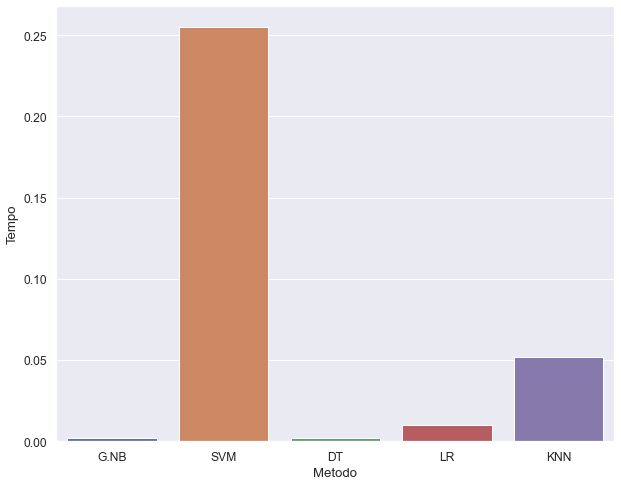

In [30]:
tempoMetodo = {}

for i, methodName in enumerate(metodos):
    
    auxTempo = [ d['timeFolds'] for d in resultadosMetodos[i] ] 
    
    tempoMetodo.update({methodName: np.mean(auxTempo)})
 
# cria  um dataframe com os tempos de cada metodo 
df_tempo = pd.DataFrame(tempoMetodo.items(), columns=['Metodo', 'Tempo'])

# definindo o tamanho da figura 
plt.figure(figsize=(10,8))

# cria um gráfico de barras 
sns.barplot(x="Metodo", y="Tempo", data=df_tempo)

# mostra o gráfico
plt.show()

Conforme pode ser visto, o SVM foi o método mais demorado. O principal motivo para isso é que a busca em grade analisou a combinação de dois parâmetros para o SVM, referentes ao *kernel* e ao parâmetro de regularização. Portanto, várias etapas de treinamento e teste foram executadas internamente pela busca em grade, uma para cada combinação de parâmetros, para que a melhor combinação fosse selecionada. O segundo método mais demorado foi o KNN, pois o cálculo da vizinhança de cada amostra é computacionalmente custoso.

Agora, vamos dar uma olhada na comparação da macro F-medida obtida por cada método.

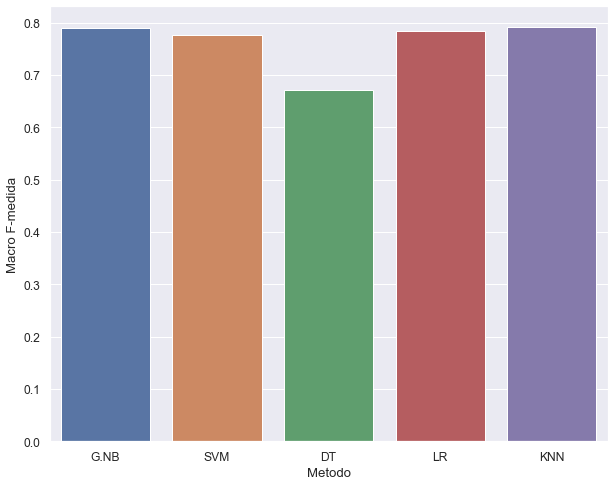

In [31]:
f1Metodo = {}

for i, methodName in enumerate(metodos):
    
    auxF1 = [ d['fmedida_macroAverage'] for d in resultadosMetodos[i] ] 
    
    f1Metodo.update({methodName: np.mean(auxF1)})
 
# cria  um dataframe com os tempos de cada metodo 
df_f1 = pd.DataFrame(f1Metodo.items(), columns=['Metodo', 'Macro F-medida'])

# definindo o tamanho da figura 
plt.figure(figsize=(10,8))

# cria um gráfico de barras 
sns.barplot(x="Metodo", y="Macro F-medida", data=df_f1)

# mostra o gráfico
plt.show()

Agora, vamos dar uma olhada na comparação da acurácia obtida por cada método.

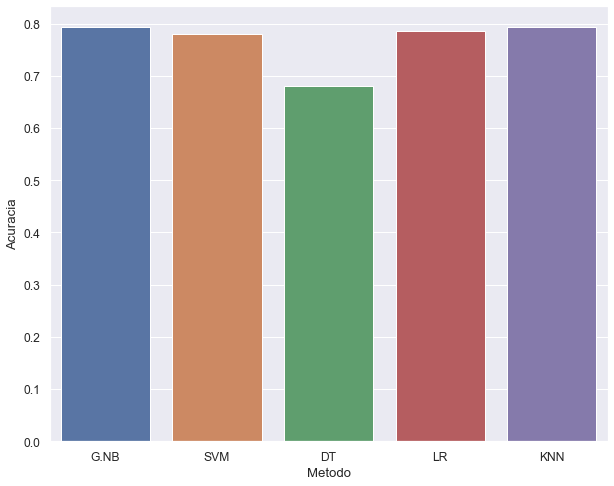

In [32]:
accMetodo = {}

for i, methodName in enumerate(metodos):
    
    auxAcc = [ d['acuracia'] for d in resultadosMetodos[i] ] 
    
    accMetodo.update({methodName: np.mean(auxAcc)})
 
# cria  um dataframe com os tempos de cada metodo 
df_acc = pd.DataFrame(accMetodo.items(), columns=['Metodo', 'Acuracia'])

# definindo o tamanho da figura 
plt.figure(figsize=(10,8))

# cria um gráfico de barras 
sns.barplot(x="Metodo", y="Acuracia", data=df_acc)

# mostra o gráfico
plt.show()

Por fim, vamos dar uma olhada na superfície de decisão de cada método para o primeiro *fold*.

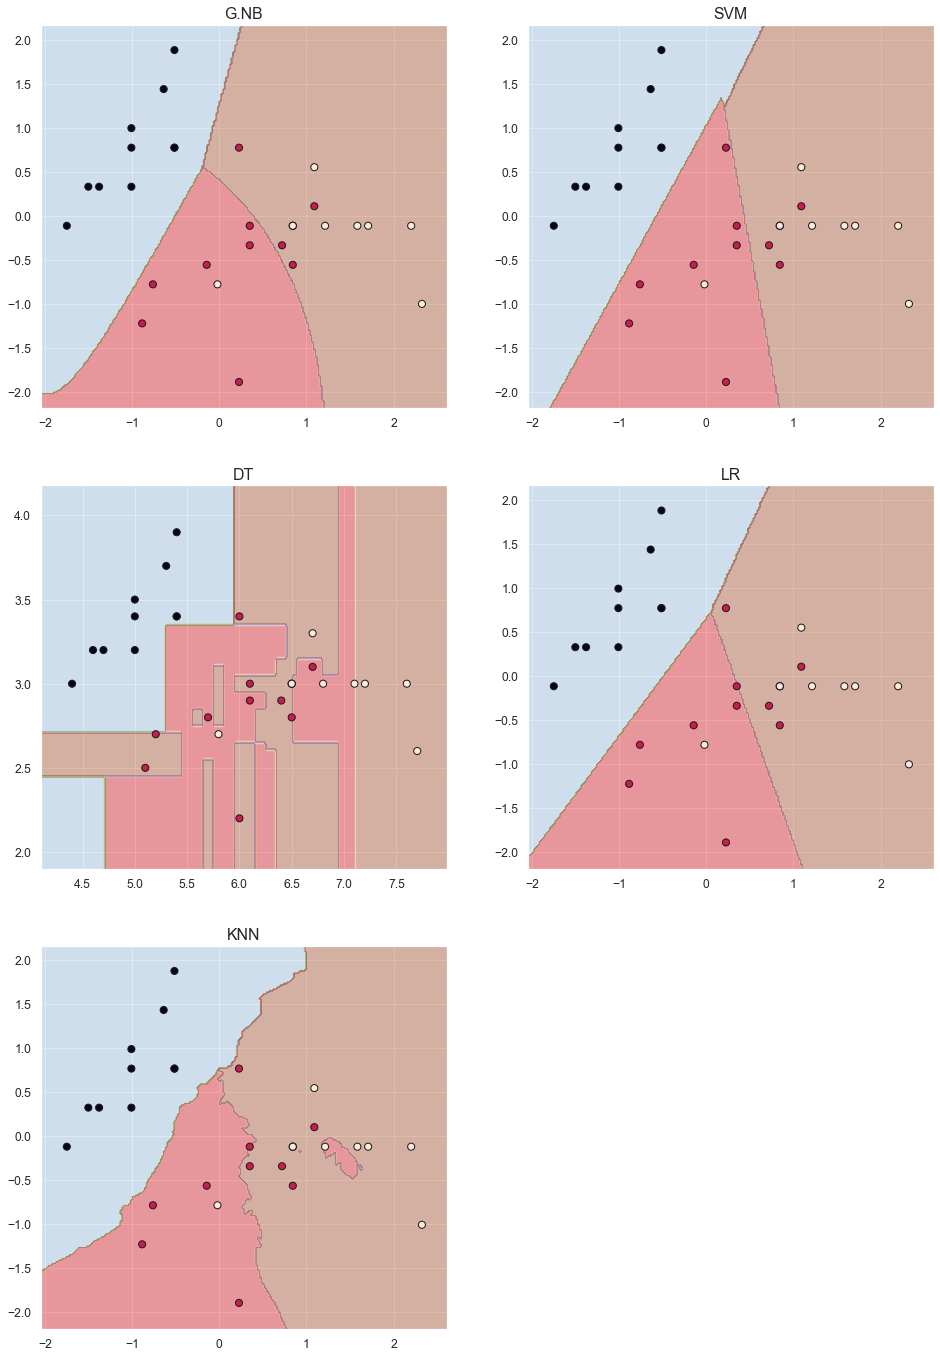

In [33]:
# define a quantidade de linhas e colunas e o tamanho da figura
nrows = 3; ncols=2; 
fig, axs = plt.subplots(nrows=nrows, ncols=ncols, figsize=(8*ncols, 8*nrows))

# apaga a ultima figura 
fig.delaxes(axs[2,1]) #The indexing is zero-based here

# converte o array em um vetor
axs = np.concatenate(axs)
    
for i, methodName in enumerate(metodos):
    
    auxClassificador = [ d['classifier'] for d in resultadosMetodos[i] ]
    
    for train_index, test_index in cv.split(X, Y):

        X_train, X_test = X[train_index, :], X[test_index, :];
        Y_train, Y_test = Y[train_index], Y[test_index];
        
        if methodName in ['G.NB', 'SVM', 'LR', 'KNN']:
            
            # normaliza os valores dos atributos para que fiquem com media igual a zero e desvio padrao igual a um
            scaler = skl.preprocessing.StandardScaler().fit(X_train)
            X_train = scaler.transform(X_train)
            X_test = scaler.transform(X_test)
    
        plota_superficieDecisao(auxClassificador[0], X_test, Y_test, axs[i], title = methodName)
        
        break

---
## Conclusão

Neste notebook, foram abordadas maneiras diferentes de realizar a análise de desempenho obtido por um ou mais métodos de classificação. Foi mostrada a técnica de validação *holdout* e a técnica de validação cruzada k-*fold*. Além disso, foi mostrado como construir uma matriz de confusão e como calcular as principais medidas de desempenho (acurácia, precisão, revocação e F-medida). Ainda, foi mostrado como fazer a seleção de parâmetros por meio da busca em grade. Por fim, foi feita a análise de desempenho de métodos de classificação que aplicam diferentes estratégias de aprendizado e predição. Para obter mais detalhes teóricos sobre as técnicas envolvidas, consulte os seguintes capítulos do livro: 4 (Métodos Baseados em Distâncias), 5 (Métodos Probabilísticos), 6 (Métodos Simbólicos), 8 (Métodos de Maximização de Margens) e 10 (Avaliação de Modelos Preditivos).

---
## Referências

[1] T. Cover, P. Hart, Nearest neighbor pattern classification, IEEE Trans. Inf. Theory
13 (1) (1967) 21–27. DOI: [10.1109/TIT.1967.1053964](http://dx.doi.org/10.1109/TIT.1967.1053964).

[2] R. A. Fisher. The use of multiple measurements in taxonomic problems. Annual Eugenics, 7, Part II, 179-188 (1936). DOI: [10.1111/j.1469-1809.1936.tb02137.x](http://dx.doi.org/10.1111/j.1469-1809.1936.tb02137.x).

[3] V. Metsis, I. Androutsopoulos, G. Paliouras (2006). Spam filtering with naive Bayes – which naive Bayes? In Proceedings of the 3rd Conference on Email and Anti-Spam (CEAS’06), pages 27–28, Mountain View, California.

[4] C. Cortes, V. Vapnik, Support-vector networks, Machine Learning 20 (3) (1995) 273–297. DOI: [10.1007/BF00994018](http://dx.doi.org/10.1007/BF00994018).

[5] L. Breiman, J. Friedman, C. J. Stone, R. A. Olshen, Classification and Regression Trees, CRC Press, Boca Raton, FL, USA, 1984. 

[6] H.-F. Yu, F.-L. Huang, C.-J. Lin (2011). Dual coordinate descent methods for logistic regression and maximum entropy models. Machine Learning, 85(1-2):41–75. DOI: [10.1007/s10994-010-5221-8](http://dx.doi.org/10.1007/s10994-010-5221-8).

---